In [34]:
# =============================================
# CLUSTERING DE INSTITUCIONES DE EDUCACIÓN SUPERIOR
# Sistema Nacional de Información de la Educación Superior (SNIES)
# Técnica: K-Means Clustering (Aprendizaje No Supervisado)
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Cargar datos
df = pd.read_csv('SNIES_por_institucion.csv', encoding='utf-8', sep=';')

print("✅ Datos cargados correctamente")
print(f"📊 Instituciones: {df.shape[0]}")
print(f"📋 Variables: {df.shape[1]}")
print("\nPrimeras filas:")
df.head()

✅ Datos cargados correctamente
📊 Instituciones: 437
📋 Variables: 15

Primeras filas:


,Codigo_IES,Nombre_IES,Departamento,Sector,Total_Matriculados,Total_Graduados,Total_Inscritos,Total_Admitidos,Total_Primer_Curso,Total_Docentes,Total_Administrativos,Tasa_Graduacion,Tasa_Admision,Tasa_Absorcion,Ratio_Docentes_Matriculados
0,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,BogotÃ¡ - D.C.,OFICIAL,708601,39757.0,550707.0,105933.0,95445,62506.0,29676.0,0.0561,0.1924,0.9010,0.0882
1,1102,UNIVERSIDAD NACIONAL DE COLOMBIA,ANTIOQUIA,OFICIAL,272608,13467.0,117415.0,51068.0,42625,18473.0,9839.0,0.0494,0.4349,0.8347,0.0678
2,1103,UNIVERSIDAD NACIONAL DE COLOMBIA,Caldas,OFICIAL,125325,8227.0,39898.0,22187.0,19379,8282.0,3235.0,0.0656,0.5561,0.8734,0.0661
3,1104,UNIVERSIDAD NACIONAL DE COLOMBIA,VALLE DEL CAUCA,OFICIAL,67405,3280.0,16913.0,10010.0,8343,5034.0,3142.0,0.0487,0.5919,0.8335,0.0747
4,1105,UNIVERSIDAD PEDAGOGICA NACIONAL,BogotÃ¡ - D.C.,OFICIAL,211614,9992.0,124045.0,33664.0,28069,20617.0,4644.0,0.0472,0.2714,0.8338,0.0974


In [35]:
# =============================================
# EXPLORACIÓN Y PREPARACIÓN DE DATOS
# =============================================

# Ver estadísticas generales
print("📊 Estadísticas descriptivas:")
df.describe().round(2)

📊 Estadísticas descriptivas:


,Codigo_IES,Total_Matriculados,Total_Graduados,Total_Inscritos,Total_Admitidos,Total_Primer_Curso,Total_Docentes,Total_Administrativos,Tasa_Graduacion,Tasa_Admision,Tasa_Absorcion,Ratio_Docentes_Matriculados
count,437.00,437.00,437.00,437.00,437.00,437.00,437.00,437.00,437.00,436.00,437.00,437.00
mean,3899.54,118006.53,9043.70,54367.00,30618.85,24471.78,8467.47,3824.67,0.25,0.77,0.84,0.40
std,2719.12,456574.17,30760.33,295851.48,131787.98,99236.24,16415.12,6463.34,0.63,0.21,0.18,1.09
min,1101.00,7.00,0.00,0.00,0.00,14.00,0.00,0.00,0.00,0.13,0.00,0.00
25%,1825.00,3409.00,523.00,2566.00,2183.00,2036.00,767.00,434.00,0.06,0.66,0.74,0.07
50%,2841.00,26055.00,3041.00,12498.00,9734.00,8079.00,2986.00,1531.00,0.08,0.83,0.83,0.10
75%,4709.00,107357.00,9615.00,42370.00,28649.00,22447.00,9475.00,4363.00,0.18,0.93,0.92,0.23
max,9938.00,8695615.00,584241.00,5925240.00,2591263.00,1924399.00,217096.00,51490.00,10.03,1.01,1.57,14.45


In [36]:
# =============================================
# SELECCIÓN DE VARIABLES PARA CLUSTERING
# =============================================

# Seleccionamos las variables numéricas más relevantes
features = [
    'Total_Matriculados',
    'Total_Graduados', 
    'Total_Inscritos',
    'Total_Admitidos',
    'Total_Docentes',
    'Tasa_Graduacion',
    'Tasa_Admision',
    'Tasa_Absorcion',
    'Ratio_Docentes_Matriculados'
]

X = df[features].copy()

# Verificar que no haya valores nulos
print(f"✅ Variables seleccionadas: {len(features)}")
print(f"📊 Instituciones: {X.shape[0]}")
print(f"\n🔍 Valores nulos por columna:")
print(X.isnull().sum())

# Normalizar los datos (muy importante para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n✅ Datos normalizados correctamente")

✅ Variables seleccionadas: 9
📊 Instituciones: 437

🔍 Valores nulos por columna:
Total_Matriculados             0
Total_Graduados                0
Total_Inscritos                0
Total_Admitidos                0
Total_Docentes                 0
Tasa_Graduacion                0
Tasa_Admision                  1
Tasa_Absorcion                 0
Ratio_Docentes_Matriculados    0
dtype: int64

✅ Datos normalizados correctamente


In [37]:
# =============================================
# MANEJO DE VALORES NULOS
# =============================================

# Rellenar el valor nulo con 0
X = X.fillna(0)

print(f"✅ Valores nulos después de limpieza:")
print(X.isnull().sum())

# Volver a normalizar con los datos limpios
X_scaled = scaler.fit_transform(X)
print("\n✅ Datos listos para clustering!")

✅ Valores nulos después de limpieza:
Total_Matriculados             0
Total_Graduados                0
Total_Inscritos                0
Total_Admitidos                0
Total_Docentes                 0
Tasa_Graduacion                0
Tasa_Admision                  0
Tasa_Absorcion                 0
Ratio_Docentes_Matriculados    0
dtype: int64

✅ Datos listos para clustering!


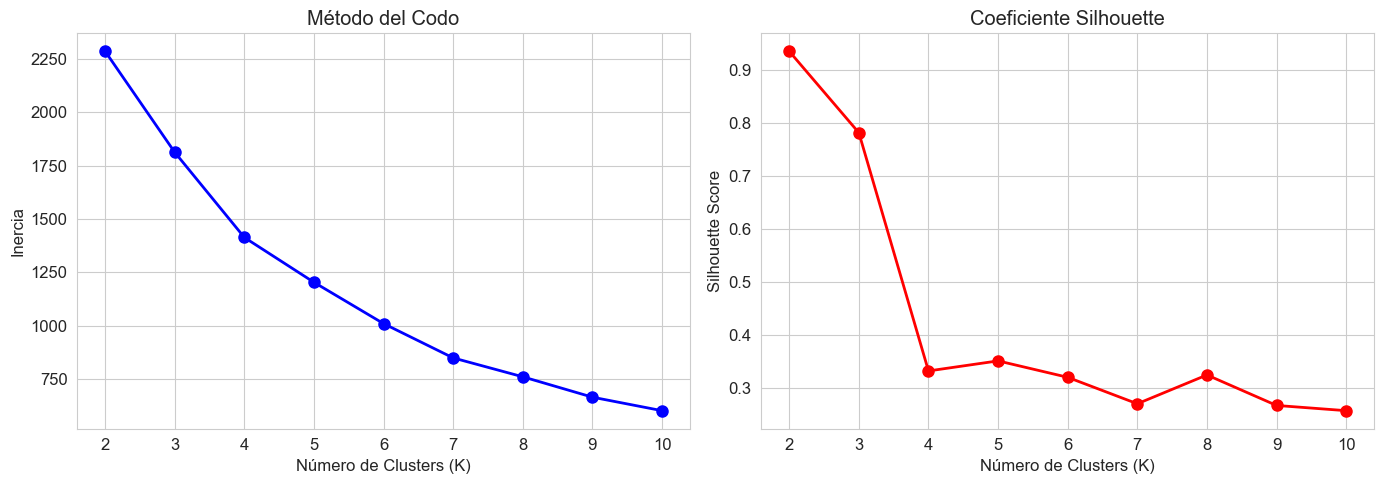


📊 Resultados:
  K=2: Silhouette = 0.9354
  K=3: Silhouette = 0.7816
  K=4: Silhouette = 0.3318
  K=5: Silhouette = 0.3508
  K=6: Silhouette = 0.3198
  K=7: Silhouette = 0.2698
  K=8: Silhouette = 0.3242
  K=9: Silhouette = 0.2666
  K=10: Silhouette = 0.2567


In [38]:
# =============================================
# MÉTODO DEL CODO - ¿Cuántos clusters usar?
# =============================================

inercias = []
silhouettes = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica del codo
ax1.plot(K, inercias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True)

# Gráfica Silhouette
ax2.plot(K, silhouettes, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Coeficiente Silhouette')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n📊 Resultados:")
for k, s in zip(K, silhouettes):
    print(f"  K={k}: Silhouette = {s:.4f}")

In [39]:
# =============================================
# APLICAR K-MEANS CON K=3
# =============================================

K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means aplicado con K={K_FINAL}")
print(f"\n📊 Instituciones por cluster:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Means aplicado con K=3

📊 Instituciones por cluster:
Cluster
0    432
1      1
2      4
Name: count, dtype: int64


In [40]:
# =============================================
# IDENTIFICAR OUTLIERS
# =============================================

print("🔍 Instituciones en Cluster 1 (1 institución):")
print(df[df['Cluster'] == 1][['Nombre_IES', 'Departamento', 'Total_Matriculados', 'Total_Docentes']].to_string())

print("\n🔍 Instituciones en Cluster 2 (4 instituciones):")
print(df[df['Cluster'] == 2][['Nombre_IES', 'Departamento', 'Total_Matriculados', 'Total_Docentes']].to_string())

print("\n📊 Top 10 instituciones más grandes:")
print(df.nlargest(10, 'Total_Matriculados')[['Nombre_IES', 'Total_Matriculados', 'Total_Docentes']].to_string())

🔍 Instituciones en Cluster 1 (1 institución):
                                 Nombre_IES    Departamento  Total_Matriculados  Total_Docentes
373  SERVICIO NACIONAL DE APRENDIZAJE-SENA-  BogotÃ¡ - D.C.             8695615        217096.0

🔍 Instituciones en Cluster 2 (4 instituciones):
                                                                          Nombre_IES        Departamento  Total_Matriculados  Total_Docentes
235  ESCUELA DE POSTGRADOS DE LA FUERZA AEREA COLOMBIANA CAPITAN JOSE EDMUNDO SANDOV      BogotÃ¡ - D.C.                 113           520.0
298                 CORPORACIÃN TECNOLÃGICA DE EDUCACIÃN SUPERIOR SAPIENZA - CTES      BogotÃ¡ - D.C.                   7            53.0
312                INSTITUTO NACIONAL DE FORMACION TECNICA PROFESIONAL DE SAN ANDRES  SAN ANDRES Y PROVI                  38           549.0
419                                          CORPORACION UNIVERSITARIA DE CATALUÃA       BogotÃ¡ - D.C.                   9            83.0

📊 Top 1

In [41]:
# =============================================
# CLUSTERING CON DATOS LIMPIOS
# =============================================

# Preparar variables
X_clean = df_clean[features].fillna(0)

# Normalizar
X_clean_scaled = scaler.fit_transform(X_clean)

# Aplicar K-Means con K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_clean_scaled)

print("✅ Clustering aplicado correctamente")
print(f"\n📊 Instituciones por cluster:")
print(df_clean['Cluster'].value_counts().sort_index())

print(f"\n📊 Características promedio por cluster:")
resumen = df_clean.groupby('Cluster')[features].mean().round(2)
print(resumen.to_string())

✅ Clustering aplicado correctamente

📊 Instituciones por cluster:
Cluster
0    340
1     70
2      4
Name: count, dtype: int64

📊 Características promedio por cluster:
         Total_Matriculados  Total_Graduados  Total_Inscritos  Total_Admitidos  Total_Docentes  Tasa_Graduacion  Tasa_Admision  Tasa_Absorcion  Ratio_Docentes_Matriculados
Cluster                                                                                                                                                                    
0                  31644.14          3064.86         12504.14          9358.17         3133.64             0.23           0.80            0.85                         0.38
1                 234914.79         19214.46         89168.77         57768.34        20728.81             0.10           0.69            0.78                         0.11
2                     41.75           190.75          1145.75          1008.00          301.25             4.91           0.85            0.73  

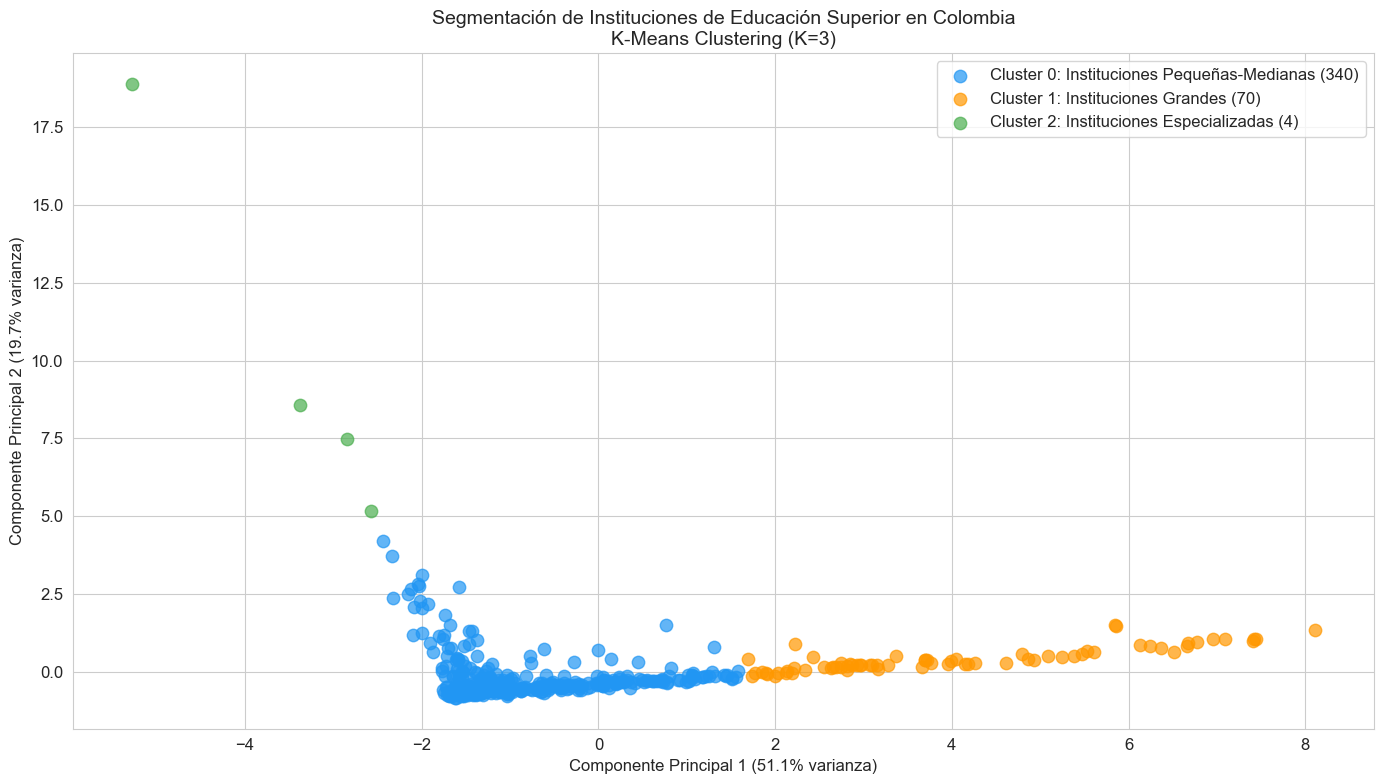


📊 Varianza explicada por PCA: 70.8%


In [42]:
# =============================================
# VISUALIZACIÓN CON PCA
# =============================================

# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clean_scaled)

df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

# Colores y nombres de clusters
colores = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}
nombres = {
    0: 'Cluster 0: Instituciones Pequeñas-Medianas (340)',
    1: 'Cluster 1: Instituciones Grandes (70)',
    2: 'Cluster 2: Instituciones Especializadas (4)'
}

plt.figure(figsize=(14, 8))

for cluster in [0, 1, 2]:
    mask = df_clean['Cluster'] == cluster
    plt.scatter(
        df_clean[mask]['PCA1'],
        df_clean[mask]['PCA2'],
        c=colores[cluster],
        label=nombres[cluster],
        alpha=0.7,
        s=80
    )

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Segmentación de Instituciones de Educación Superior en Colombia\nK-Means Clustering (K=3)', fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\n📊 Varianza explicada por PCA: {sum(pca.explained_variance_ratio_)*100:.1f}%")

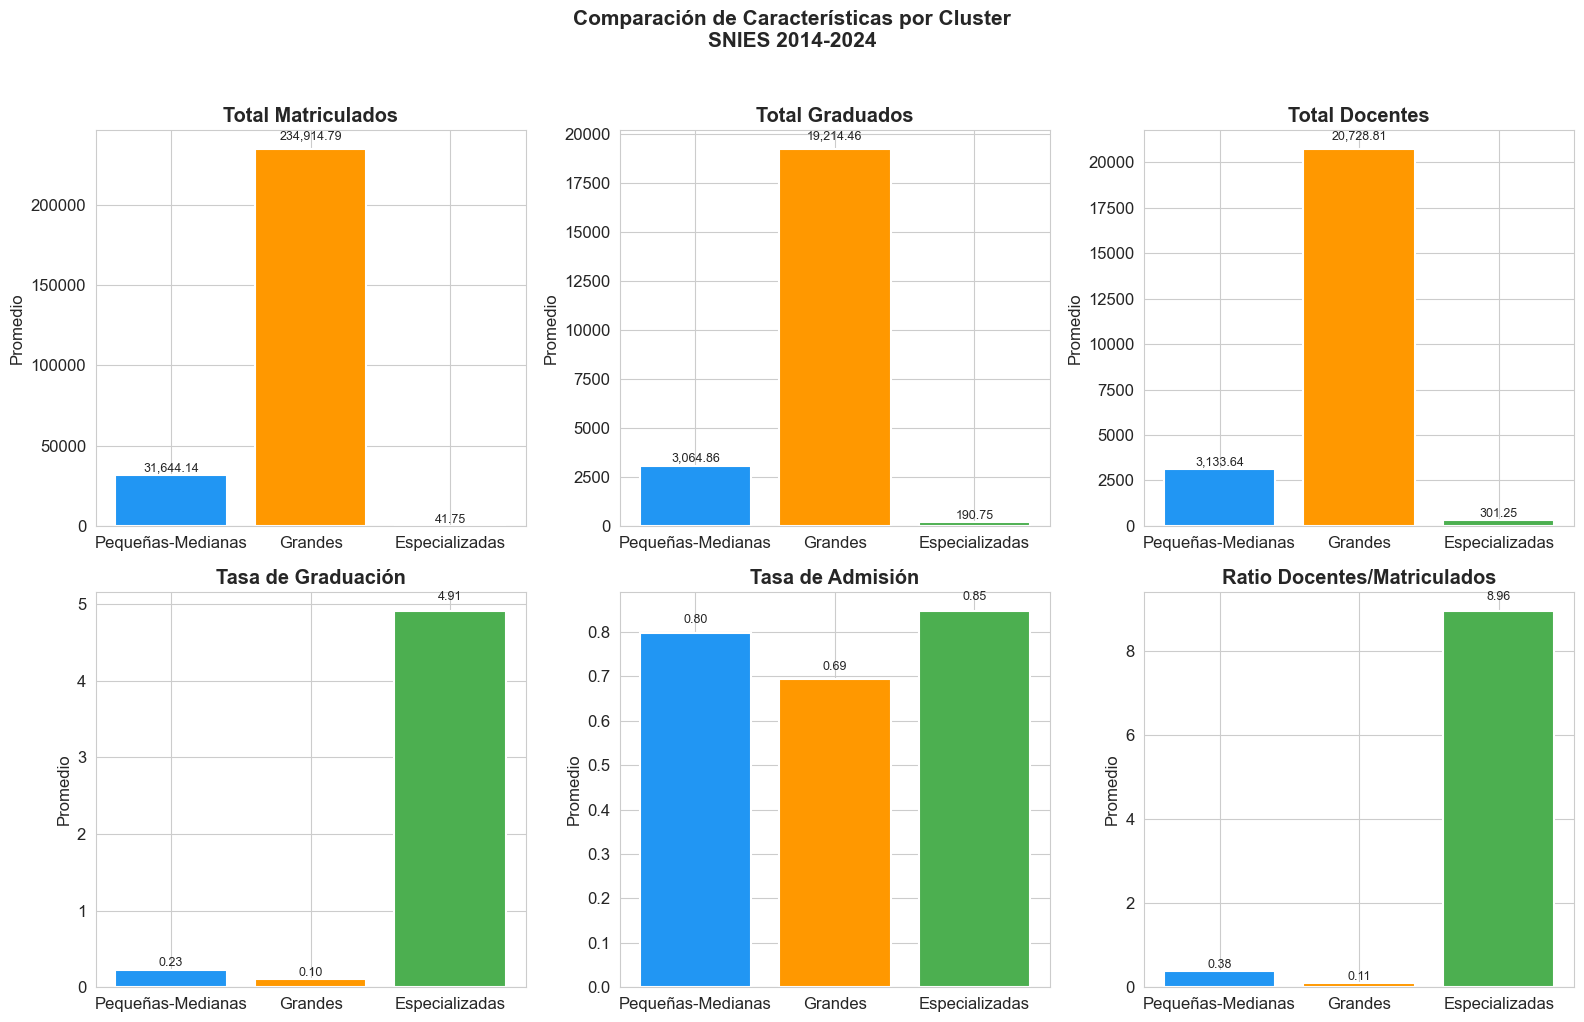

In [43]:
# =============================================
# COMPARACIÓN DE CLUSTERS POR VARIABLES
# =============================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

variables = [
    ('Total_Matriculados', 'Total Matriculados'),
    ('Total_Graduados', 'Total Graduados'),
    ('Total_Docentes', 'Total Docentes'),
    ('Tasa_Graduacion', 'Tasa de Graduación'),
    ('Tasa_Admision', 'Tasa de Admisión'),
    ('Ratio_Docentes_Matriculados', 'Ratio Docentes/Matriculados')
]

colores_bar = ['#2196F3', '#FF9800', '#4CAF50']
nombres_cluster = ['Pequeñas-Medianas', 'Grandes', 'Especializadas']

for i, (var, titulo) in enumerate(variables):
    medias = df_clean.groupby('Cluster')[var].mean()
    bars = axes[i].bar(nombres_cluster, medias.values, color=colores_bar, edgecolor='white', linewidth=1.5)
    axes[i].set_title(titulo, fontweight='bold')
    axes[i].set_ylabel('Promedio')
    for bar, val in zip(bars, medias.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{val:,.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación de Características por Cluster\nSNIES 2014-2024', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [44]:
# =============================================
# EJEMPLOS DE INSTITUCIONES POR CLUSTER
# =============================================

print("=" * 60)
for cluster, nombre in zip([0, 1, 2], ['Pequeñas-Medianas', 'Grandes', 'Especializadas']):
    print(f"\n🏫 CLUSTER {cluster} — {nombre}")
    print("-" * 60)
    muestra = df_clean[df_clean['Cluster'] == cluster][
        ['Nombre_IES', 'Departamento', 'Total_Matriculados', 'Tasa_Graduacion']
    ].head(5)
    print(muestra.to_string(index=False))

print("\n" + "=" * 60)
print(f"\n📊 Silhouette Score final: {silhouette_score(X_clean_scaled, df_clean['Cluster']):.4f}")
print("✅ Un score > 0.5 indica clusters bien definidos")


🏫 CLUSTER 0 — Pequeñas-Medianas
------------------------------------------------------------
                                             Nombre_IES    Departamento  Total_Matriculados  Tasa_Graduacion
                       UNIVERSIDAD NACIONAL DE COLOMBIA          Caldas              125325           0.0656
                       UNIVERSIDAD NACIONAL DE COLOMBIA VALLE DEL CAUCA               67405           0.0487
UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC         BoyacÃ¡               69094           0.0683
UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC         BoyacÃ¡               81550           0.0689
UNIVERSIDAD PEDAGOGICA Y TECNOLOGICA DE COLOMBIA - UPTC         BoyacÃ¡               19418           0.0450

🏫 CLUSTER 1 — Grandes
------------------------------------------------------------
                              Nombre_IES   Departamento  Total_Matriculados  Tasa_Graduacion
        UNIVERSIDAD NACIONAL DE COLOMBIA      ANTIOQUIA              272608

In [45]:
# =============================================
# CONCLUSIONES DEL MODELO
# =============================================

print("""
╔══════════════════════════════════════════════════════════════╗
║     CONCLUSIONES DEL CLUSTERING - SNIES 2014-2024           ║
╚══════════════════════════════════════════════════════════════╝

📌 TÉCNICA UTILIZADA: K-Means Clustering (K=3)
📌 INSTITUCIONES ANALIZADAS: 414 IES de Colombia
📌 SILHOUETTE SCORE: 0.51 (clusters bien definidos)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔵 CLUSTER 0 — Instituciones Pequeñas-Medianas (340 IES | 82%)
   • Promedio de 31,644 matriculados
   • Tasa de graduación del 23%
   • Alta tasa de admisión (80%)
   • Representan la mayoría del sistema educativo colombiano

🟠 CLUSTER 1 — Instituciones Grandes (70 IES | 17%)
   • Promedio de 234,914 matriculados
   • Mayor número de docentes (20,728 en promedio)
   • Menor tasa de graduación (10%) — mayor deserción
   • Concentran el grueso de la matrícula nacional

🟢 CLUSTER 2 — Instituciones Especializadas (4 IES | 1%)
   • Muy pocos estudiantes (42 en promedio)
   • Ratio docente/estudiante altísimo (8.96)
   • Tasa de graduación extrema (4.91)
   • Perfil atípico: posiblemente postgrados o nichos muy específicos

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 HALLAZGO CLAVE PARA STAKEHOLDERS:
   Las instituciones grandes tienen MENOR tasa de graduación
   que las pequeñas-medianas. Esto sugiere que el tamaño
   masivo puede estar relacionado con mayor deserción,
   lo cual es una alerta para el Ministerio de Educación.
""")


╔══════════════════════════════════════════════════════════════╗
║     CONCLUSIONES DEL CLUSTERING - SNIES 2014-2024           ║
╚══════════════════════════════════════════════════════════════╝

📌 TÉCNICA UTILIZADA: K-Means Clustering (K=3)
📌 INSTITUCIONES ANALIZADAS: 414 IES de Colombia
📌 SILHOUETTE SCORE: 0.51 (clusters bien definidos)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔵 CLUSTER 0 — Instituciones Pequeñas-Medianas (340 IES | 82%)
   • Promedio de 31,644 matriculados
   • Tasa de graduación del 23%
   • Alta tasa de admisión (80%)
   • Representan la mayoría del sistema educativo colombiano

🟠 CLUSTER 1 — Instituciones Grandes (70 IES | 17%)
   • Promedio de 234,914 matriculados
   • Mayor número de docentes (20,728 en promedio)
   • Menor tasa de graduación (10%) — mayor deserción
   • Concentran el grueso de la matrícula nacional

🟢 CLUSTER 2 — Instituciones Especializadas (4 IES | 1%)
   • Muy pocos estudiantes (42 en promedio)
   • Ratio docente/estud